In [1]:
# === ノートブック共通の前処理 (llm_math パッケージの読み込み) ===
import sys
from pathlib import Path

# llm_math パッケージの候補パス
_candidates = [
    '.', 'src', '..', '../src',
    '/content/llm-math-book/src',
    '/content/llm-math-book',
    '/workspace/src',
    '/workspace',
]
# 親ディレクトリも候補に追加 (notebooks/ フォルダで実行する場合)
for p in Path.cwd().parents:
    _candidates.append(str(p / 'src'))
    _candidates.append(str(p))

for p in _candidates:
    if p and p not in sys.path and Path(p).exists():
        sys.path.insert(0, p)

# llm_math の import を試行
try:
    from llm_math import viz, bench, data
    _LLM_MATH_OK = True
except ImportError as e:
    _LLM_MATH_OK = False
    print(f"[注意] llm_math パッケージの読み込み テキスト: {e}")
    print("  GitHub リポジトリを clone して colab_setup.sh を実行してください。")
# === 前処理ここまで ===


# Ch 01. ベクトルテキスト 空間 — テキスト テキスト

> **学習目標**
> - ベクトルテキスト 空間テキスト テキスト テキスト テキスト テキスト
> - 内積, ノルム, テキスト テキスト テキスト テキスト テキスト
> - コサイン類似度テキスト LLM テキスト テキスト テキスト テキスト

## 1.1 ベクトルテキスト テキスト

ベクトルテキスト **テキスト テキスト テキスト テキスト**テキスト. テキスト テキスト テキスト テキスト テキスト テキスト テキスト:

1. **テキスト テキスト**: $\mathbf{x} = [x_1, x_2, \ldots, x_n]^\top \in \mathbb{R}^n$
2. **テキスト テキスト**: 空間テキスト テキスト テキスト, テキスト テキスト テキスト テキスト テキスト テキスト

LLMテキスト テキスト テキスト 768次元テキスト 4096次元 ベクトルテキスト テキスト. テキスト 2~3次元テキスト テキスト テキスト テキスト.


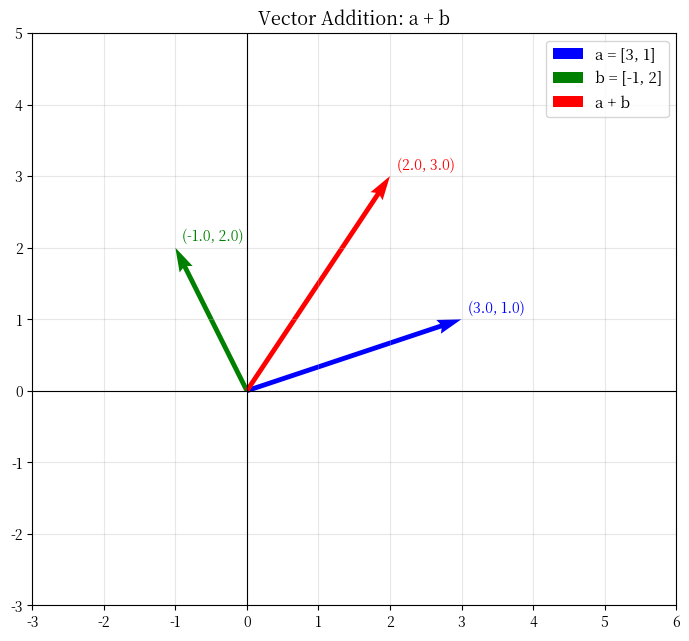

Vector a = [3. 1.] | b = [-1.  2.] | a + b = [2. 3.]


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from llm_math.viz import plot_vector_2d, setup_axes_2d

# 2次元 ベクトル テキスト
a = np.array([3.0, 1.0])
b = np.array([-1.0, 2.0])
c = a + b   # ベクトル テキスト

fig, ax = plt.subplots(1, 1, figsize=(7, 7))
plot_vector_2d(ax, a, color='blue', label='a = [3, 1]')
plot_vector_2d(ax, b, color='green', label='b = [-1, 2]')
plot_vector_2d(ax, c, color='red', label='a + b')
setup_axes_2d(ax, xlim=(-3, 6), ylim=(-3, 5))
ax.legend(fontsize=11)
ax.set_title('Vector Addition: a + b', fontsize=13)
plt.tight_layout()
plt.savefig('../figures/ch01_vector_addition.png', dpi=100, bbox_inches='tight')
plt.show()
print("Vector a =", a, "| b =", b, "| a + b =", c)


## 1.2 ベクトル テキスト テキスト テキスト

### テキスト (Scalar Multiplication)

$\alpha \mathbf{x} = [\alpha x_1, \alpha x_2, \ldots]^\top$

ベクトルテキスト テキスト $\alpha$テキスト テキスト テキスト. $\alpha < 0$テキスト 方向テキスト テキスト テキスト.

### 内積 (Dot Product)

$$\mathbf{a} \cdot \mathbf{b} = \sum_{i=1}^{n} a_i b_i = \|\mathbf{a}\| \|\mathbf{b}\| \cos\theta$$

内積テキスト テキスト ベクトルテキスト **テキスト テキスト 方向テキスト テキスト**テキスト テキスト 度テキスト.
- $\cos\theta = 1$ (テキスト 方向): 内積 テキスト
- $\cos\theta = 0$ (テキスト): 内積 = 0
- $\cos\theta = -1$ (テキスト 方向): 内積 テキスト


In [3]:
# 内積 計算
a = np.array([3.0, 1.0])
b = np.array([-1.0, 2.0])

dot = np.dot(a, b)
print(f"a · b = {a[0]}*{b[0]} + {a[1]}*{b[1]} = {dot}")

# Inner Product = |a||b|cos(theta) テキスト
norm_a = np.linalg.norm(a)
norm_b = np.linalg.norm(b)
cos_theta = dot / (norm_a * norm_b)
theta_rad = np.arccos(np.clip(cos_theta, -1, 1))
theta_deg = np.degrees(theta_rad)
print(f"|a| = {norm_a:.4f}, |b| = {norm_b:.4f}")
print(f"cos(theta) = {cos_theta:.4f}")
print(f"theta = {theta_deg:.2f} degrees")
print(f"Validation: |a||b|cos(theta) = {norm_a * norm_b * cos_theta:.4f} == dot = {dot:.4f}")


a · b = 3.0*-1.0 + 1.0*2.0 = -1.0
|a| = 3.1623, |b| = 2.2361
cos(theta) = -0.1414
theta = 98.13 degrees
Validation: |a||b|cos(theta) = -1.0000 == dot = -1.0000


## 1.3 ノルムテキスト テキスト

ノルム(norm)テキスト ベクトルテキスト "テキスト"テキスト テキスト 関数テキスト. テキスト テキスト テキスト:

$$\|\mathbf{x}\|_p = \left(\sum_{i=1}^{n} |x_i|^p\right)^{1/p}$$

- $L^1$ ノルム ($p=1$): $\sum_i |x_i|$ — テキスト テキスト
- $L^2$ ノルム ($p=2$): $\sqrt{\sum_i x_i^2}$ — テキスト テキスト
- $L^\infty$ ノルム: $\max_i |x_i|$ — テキスト値

LLMテキスト $L^2$ ノルムテキスト テキスト テキスト テキスト (LayerNorm, テキスト テキスト, テキスト テキスト).


In [4]:
# テキスト ノルム 比較
x = np.array([3.0, -4.0])

l1 = np.sum(np.abs(x))
l2 = np.sqrt(np.sum(x**2))
linf = np.max(np.abs(x))

print(f"x = {x}")
print(f"L1 norm   = |3| + |-4|          = {l1}")
print(f"L2 norm   = sqrt(3^2 + 4^2)     = {l2}")
print(f"L-inf norm = max(|3|, |-4|)      = {linf}")
print()
print("NumPy Validation:")
print(f"  np.linalg.norm(x, 1)  = {np.linalg.norm(x, 1)}")
print(f"  np.linalg.norm(x, 2)  = {np.linalg.norm(x, 2)}")
print(f"  np.linalg.norm(x, np.inf) = {np.linalg.norm(x, np.inf)}")


x = [ 3. -4.]
L1 norm   = |3| + |-4|          = 7.0
L2 norm   = sqrt(3^2 + 4^2)     = 5.0
L-inf norm = max(|3|, |-4|)      = 4.0

NumPy Validation:
  np.linalg.norm(x, 1)  = 7.0
  np.linalg.norm(x, 2)  = 5.0
  np.linalg.norm(x, np.inf) = 4.0


## 1.4 テキスト テキスト度

### テキスト テキスト
$$d(\mathbf{a}, \mathbf{b}) = \|\mathbf{a} - \mathbf{b}\|_2 = \sqrt{\sum_i (a_i - b_i)^2}$$

### コサイン類似度 (Cosine Similarity)
$$\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\| \, \|\mathbf{b}\|} \in [-1, 1]$$

LLM テキスト テキスト/テキスト テキスト度テキスト **コサイン類似度**テキスト テキスト.
テキスト テキスト:
1. テキスト ベクトルテキスト "方向"テキスト テキスト, "テキスト"テキスト テキスト度 テキスト テキスト テキスト テキスト テキスト テキスト
2. テキスト次元テキスト テキスト テキスト テキスト テキスト テキスト


In [5]:
# コサイン類似度 テキスト テキスト
def cosine_similarity(a, b):
    """Cosine Similarity (cosine similarity)."""
    dot = np.dot(a, b)
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return 0.0
    return dot / (norm_a * norm_b)

# テキスト: 3テキスト word Embedding (テキスト)
king   = np.array([0.9, 0.8, 0.3])
queen  = np.array([0.85, 0.85, 0.4])
apple  = np.array([0.1, 0.2, 0.9])

print(f"cos(king, queen)  = {cosine_similarity(king, queen):.4f}  (テキスト テキスト)")
print(f"cos(king, apple)  = {cosine_similarity(king, apple):.4f}  (テキスト テキスト)")
print(f"cos(queen, apple) = {cosine_similarity(queen, apple):.4f} (テキスト テキスト)")

# テキスト テキスト 比較
print()
print(f"euclidean(king, queen)  = {np.linalg.norm(king - queen):.4f}  (テキスト テキスト)")
print(f"euclidean(king, apple)  = {np.linalg.norm(king - apple):.4f}  (テキスト テキスト)")


cos(king, queen)  = 0.9954  (テキスト テキスト)
cos(king, apple)  = 0.4518  (テキスト テキスト)
cos(queen, apple) = 0.5235 (テキスト テキスト)

euclidean(king, queen)  = 0.1225  (テキスト テキスト)
euclidean(king, apple)  = 1.1662  (テキスト テキスト)


## 1.5 ベクトル 空間テキスト テキスト 空間

**ベクトル 空間(vector space)**テキスト ベクトルテキスト テキスト, テキスト テキスト テキスト テキスト テキスト.

**テキスト テキスト(linear combination)**: $\alpha \mathbf{a} + \beta \mathbf{b}$
- テキスト ベクトルテキスト テキスト テキスト 結果

**Span**: テキスト ベクトルテキスト テキスト テキスト テキスト テキスト テキスト テキスト テキスト
- $\text{span}(\{\mathbf{e}_1, \mathbf{e}_2\})$ = $\mathbb{R}^2$ テキスト

**テキスト(basis)**: ベクトル 空間テキスト テキスト テキスト テキスト ベクトルテキスト テキスト
- $\mathbb{R}^n$テキスト テキスト テキスト: $\mathbf{e}_1 = [1,0,\ldots], \mathbf{e}_2 = [0,1,0,\ldots], \ldots$


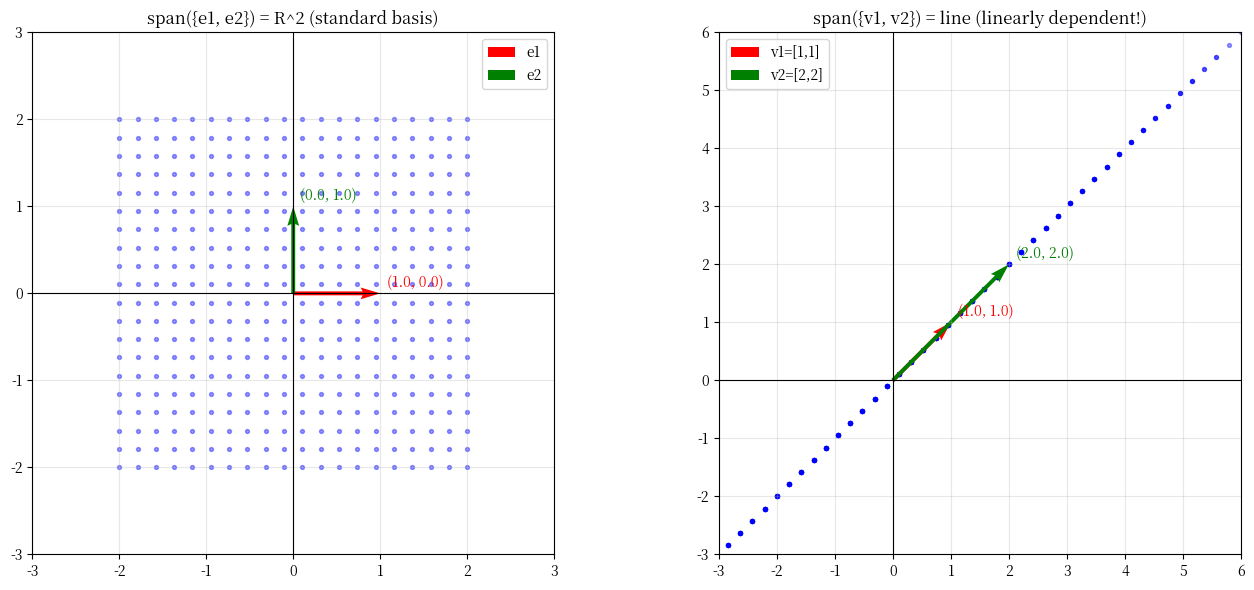

テキスト: Linear Independentテキスト Basisテキスト 2D テキストPlane テキスト Generation
テキスト: Linear Dependentテキスト テキスト Vectorテキスト テキストLine(1D SubspaceSpace)テキスト Generation


In [6]:
# Span 可視化: テキスト ベクトルテキスト テキスト テキスト テキスト テキスト テキスト テキスト
e1 = np.array([1.0, 0.0])
e2 = np.array([0.0, 1.0])

# テキスト alpha, beta テキスト
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# テキスト テキスト
ax = axes[0]
alphas = np.linspace(-2, 2, 20)
betas = np.linspace(-2, 2, 20)
points = []
for a in alphas:
    for b in betas:
        points.append(a * e1 + b * e2)
points = np.array(points)
ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.4, color='blue')
plot_vector_2d(ax, e1, color='red', label='e1')
plot_vector_2d(ax, e2, color='green', label='e2')
setup_axes_2d(ax, xlim=(-3, 3), ylim=(-3, 3))
ax.set_title('span({e1, e2}) = R^2 (standard basis)')
ax.legend()

# テキスト テキスト テキスト ベクトル (テキスト 方向)
ax = axes[1]
v1 = np.array([1.0, 1.0])
v2 = np.array([2.0, 2.0])  # v1テキスト テキスト 方向
points = []
for a in alphas:
    for b in betas:
        points.append(a * v1 + b * v2)
points = np.array(points)
ax.scatter(points[:, 0], points[:, 1], s=8, alpha=0.4, color='blue')
plot_vector_2d(ax, v1, color='red', label='v1=[1,1]')
plot_vector_2d(ax, v2, color='green', label='v2=[2,2]')
setup_axes_2d(ax, xlim=(-3, 6), ylim=(-3, 6))
ax.set_title('span({v1, v2}) = line (linearly dependent!)')
ax.legend()
plt.tight_layout()
plt.savefig('../figures/ch01_span.png', dpi=100, bbox_inches='tight')
plt.show()
print("テキスト: Linear Independentテキスト Basisテキスト 2D テキストPlane テキスト Generation")
print("テキスト: Linear Dependentテキスト テキスト Vectorテキスト テキストLine(1D SubspaceSpace)テキスト Generation")


## 1.6 テキスト: テキスト テキスト コサイン類似度

LLMテキスト テキスト テキスト~テキスト 次元 ベクトルテキスト テキスト. テキスト テキスト テキスト テキスト 方向テキスト テキスト.
テキスト テキスト テキスト 3次元 テキスト テキスト テキスト度テキスト 計算テキスト テキスト.


In [7]:
# テキスト テキスト テキスト テキスト (3次元テキスト テキスト)
# テキスト 次元テキスト [テキスト, テキスト, テキスト]テキスト テキスト テキスト
words = {
    'king':    np.array([0.99, 0.70, 0.05]),
    'queen':   np.array([0.95, 0.95, 0.05]),
    'man':     np.array([0.50, 0.10, 0.05]),
    'woman':   np.array([0.50, 0.90, 0.05]),
    'apple':   np.array([0.05, 0.40, 0.95]),
    'orange':  np.array([0.05, 0.30, 0.92]),
    'banana':  np.array([0.05, 0.20, 0.90]),
}

# Cosine Similarity Matrix Computation
word_list = list(words.keys())
n = len(word_list)
sim_matrix = np.zeros((n, n))
for i, w1 in enumerate(word_list):
    for j, w2 in enumerate(word_list):
        sim_matrix[i, j] = cosine_similarity(words[w1], words[w2])

print("Cosine Similarity Matrix:")
print(f"{'':>10}", end='')
for w in word_list:
    print(f"{w:>10}", end='')
print()
for i, w1 in enumerate(word_list):
    print(f"{w1:>10}", end='')
    for j, w2 in enumerate(word_list):
        print(f"{sim_matrix[i, j]:>10.3f}", end='')
    print()

# テキスト テキスト word テキスト
print("\n'king'テキスト テキスト テキスト word:")
king_idx = word_list.index('king')
sims = sim_matrix[king_idx].copy()
sims[king_idx] = -1  # テキスト テキスト テキスト
top2 = np.argsort(-sims)[:3]
for idx in top2:
    print(f"  {word_list[idx]:>10}: {sims[idx]:.4f}")


Cosine Similarity Matrix:
                king     queen       man     woman     apple    orange    banana
      king     1.000     0.986     0.913     0.901     0.301     0.260     0.209
     queen     0.986     1.000     0.831     0.962     0.342     0.291     0.228
       man     0.913     0.831     1.000     0.649     0.213     0.203     0.190
     woman     0.901     0.962     0.649     1.000     0.407     0.341     0.263
     apple     0.301     0.342     0.213     0.407     1.000     0.997     0.984
    orange     0.260     0.291     0.203     0.341     0.997     1.000     0.995
    banana     0.209     0.228     0.190     0.263     0.984     0.995     1.000

'king'テキスト テキスト テキスト word:
       queen: 0.9856
         man: 0.9128
       woman: 0.9014


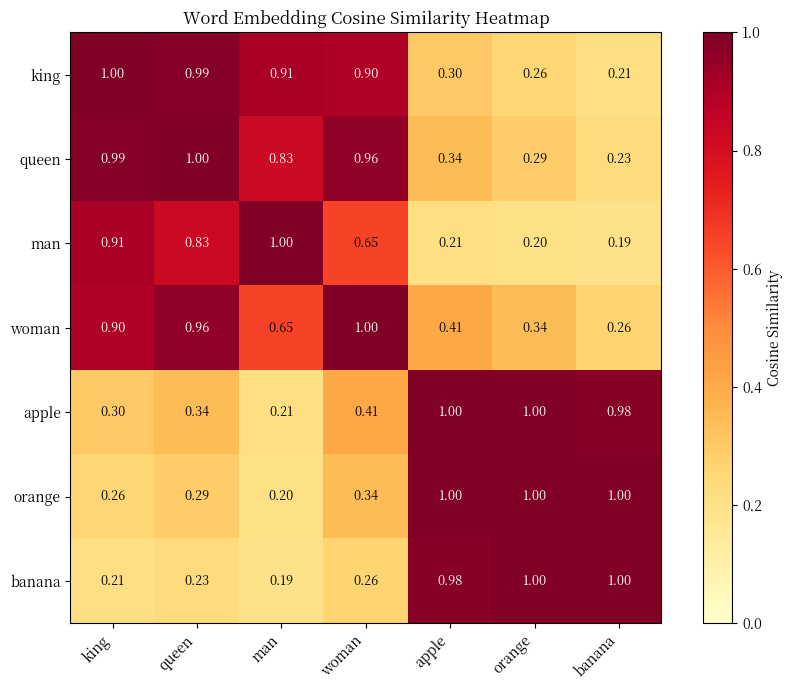

In [8]:
# テキスト度 行列 テキスト 可視化
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(sim_matrix, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_xticks(range(n))
ax.set_yticks(range(n))
ax.set_xticklabels(word_list, rotation=45, ha='right')
ax.set_yticklabels(word_list)
plt.colorbar(im, ax=ax, label='Cosine Similarity')
ax.set_title('Word Embedding Cosine Similarity Heatmap')

# 値 テキスト
for i in range(n):
    for j in range(n):
        ax.text(j, i, f'{sim_matrix[i, j]:.2f}', ha='center', va='center',
                color='black' if sim_matrix[i, j] < 0.7 else 'white', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/ch01_word_similarity.png', dpi=100, bbox_inches='tight')
plt.show()


## 1.7 要点

| テキスト | テキスト | テキスト |
|---|---|---|
| ベクトル ノルム | $\|\mathbf{x}\|_p$ | ベクトルテキスト テキスト |
| 内積 | $\mathbf{a} \cdot \mathbf{b}$ | テキスト 方向テキスト テキスト度 |
| コサイン類似度 | $\frac{\mathbf{a} \cdot \mathbf{b}}{\|\mathbf{a}\|\|\mathbf{b}\|}$ | 方向テキスト 比較 (テキスト テキスト) |
| テキスト テキスト | $\|\mathbf{a} - \mathbf{b}\|_2$ | テキスト テキスト |
| Span | $\text{span}(\{\mathbf{v}_i\})$ | テキスト テキスト テキスト テキスト テキスト テキスト |

## 演習問題

1. 3次元 ベクトル $\mathbf{a} = [1, 2, 3]$, $\mathbf{b} = [4, -1, 0]$テキスト テキスト 内積, $L^2$ ノルム, コサイン類似度テキスト 計算テキスト.
2. テキスト ベクトルテキスト テキスト テキスト 内積テキスト テキスト? テキスト 0テキスト テキスト テキスト テキスト テキスト.
3. $\mathbf{v}_1 = [1, 2]$, $\mathbf{v}_2 = [2, 4]$テキスト テキスト テキスト? テキスト テキスト.
4. テキスト 5次元 ベクトル $\mathbf{x}$テキスト テキスト $\|\mathbf{x}\|_1 \geq \|\mathbf{x}\|_2 \geq \|\mathbf{x}\|_\infty$テキスト テキスト テキスト テキスト.
5. テキスト テキスト テキスト 'man'テキスト 'woman'テキスト コサイン類似度テキスト 'man'テキスト 'apple'テキスト テキスト テキスト テキスト 次元 テキスト テキスト.

> 解答: `solutions/ch01_solutions.ipynb`
